# Supplementary Information for VLLE Water + Butanol + DMC

*A. Ulloa, M. Cartes, G. Alonso, A. Mejía*

We import the needed SGTpy modules to build a mixture and model its phases with SAFT-VR Mie EoS and interfaces with SGT. Here we use the *component* function to load each pure component's SAFT parameters (*i.e.,* $m_{s,i}$, $\sigma_i$, $\varepsilon_i$, $\lambda_r$,$\lambda_a$, $n_{pol}$ and $\mu_{pol}$, the association parameters $\varepsilon_{ii}^{AB}$, $r_{c,ii}^{AB}$, $r_{dc,ii}^{AB}$ and the association scheme sites=[B,P,N]) 

Then each pure component is combined into a mixture by adding them together as c1 + c2 + c3 into the mix variable, where the binary interaction parameters for SAFT for associative pairs (*i.e.,* $k_{ij}$ matrix and $l_{ij}$ matrix) and SGT (*i.e.,* $\beta_{ij}$ matrix) can be loaded:

**SAFT cross-interaction**   $\varepsilon_{ij}=\sqrt{\varepsilon_i \varepsilon_j}\frac{\sqrt{\sigma_i^3 \sigma_j^3}}{\sigma_{ij}^3}(1-k_{ij})$

**SAFT cross-association**  $\varepsilon_{ij}^{AB}=\sqrt{\varepsilon_{ii}^{AB} \varepsilon_{jj}^{AB}}(1-l_{ij})$

**SGT cross-interaction**   $c_{ij} = \sqrt(c_{ii}c_{ij})*(1-\beta_{ij})$

Finally, the mixture is loaded into the EoS with the *saftvrmie* function and the induced associative parameters are manually placed. For more information about how to set up a a mixture with SGTpy we refer the reader to the original GitHub documentation and examples page: 

https://github.com/gustavochm/sgtpy

https://github.com/gustavochm/sgtpy/blob/master/examples/

### First block
in this block all sub-binary mixtures and the ternary mixture are defined. Binary mixtures will be used to define the thermodynamic limits of the ternary mixture, but will not be specifially used to extract data in this SI.

In [1]:
import numpy as np
from sgtpy import component, mixture, saftvrmie
from sgtpy.equilibrium import vlle, vlleb
from scipy.optimize import minimize
from sgtpy.sgt import sgt_mix, msgt_mix, sgt_mix_beta0
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

c1 = component('water',     Mw = 18.02, ms = 1.731, sigma = 2.454, eps = 110.85, lambda_r =  8.308, lambda_a = 6.0, eAB = 1991.07, rcAB = 0.5624, rdAB = 0.4, sites = [0,2,2], cii = 1.5371939421515458e-20)
c2 = component('butanol2C', Mw = 74.12, ms = 1.965, sigma = 4.108, eps = 277.89, lambda_r = 10.669, lambda_a = 6.0, eAB = 3300.00, rcAB = 0.2615, rdAB = 0.4, sites = [1,0,1], npol = 1.450, mupol = 1.661, cii = 1.4311e-19)
c3 = component('DMC',       Mw = 90.08, ms = 2.864, sigma = 3.431, eps = 277.20, lambda_r = 11.895, lambda_a = 6.0,                                           sites = [0,0,3], npol = 1.666, mupol = 0.910, cii  = 1.83741007e-19)  

#-----------------------------------------------
# Water(1) + Butanol(2)
#-----------------------------------------------
mix12 = c1 + c2
mix12.kij_saft(np.array([[ 0,        -0.00736 ],
                       [ -0.00736,   0 ]]))
mix12.lij_saft(np.array([[0,         -0.00737],
                       [-0.00737,   0]]))
eos12 = saftvrmie(mix12)
eos12.beta_sgt([[0,      0],
                [0,      0]])
#-----------------------------------------------
# Water(1) + DMC(3)
#-----------------------------------------------
mix13 = c1 + c3
mix13.kij_saft(np.array([[ 0,        0.05588 ],
                         [ 0.05588,  0 ]]))
eos13 = saftvrmie(mix13)
eos13.beta_sgt([[0,      0.0149],
                [0.0149,      0]])
eos13.eABij[1,0], eos13.eABij[0,1] = c1.eAB/2, c1.eAB/2
eos13.rcij[1,0],  eos13.rcij[0,1]  = 2.261 * 1e-10, 2.261 * 1e-10
#-----------------------------------------------
# Butanol(2) + DMC(3)
#-----------------------------------------------
mix23 = c2 + c3
mix23.kij_saft(np.array([[ 0,        0.0371 ],
                         [ 0.0371,   0 ]]))
eos23 = saftvrmie(mix23)
eos23.beta_sgt([[0,      0.0149],
                [0.0149,      0]])
eos23.eABij[1,0], eos23.eABij[0,1] = c2.eAB/2, c2.eAB/2
eos23.rcij[1,0],  eos23.rcij[0,1]  = 1.589 * 1e-10, 1.589 * 1e-10
#-----------------------------------------------
# Water(1) + Butanol(2) + DMC(3)
#-----------------------------------------------
mix = c1 + c2 + c3
mix.kij_saft(np.array([[ 0,        -0.00736,    0.05588 ],
                       [-0.00736,   0,          0.0371 ],
                       [ 0.05588,   0.0371,     0 ]]))
mix.lij_saft(np.array([[0,         -0.00737,     0],
                       [-0.00737,   0,           0],
                       [0,          0,           0]]))

eos = saftvrmie(mix)
eos.eABij[2,0], eos.eABij[0,2] = c1.eAB/2, c1.eAB/2
eos.eABij[2,1], eos.eABij[1,2] = c2.eAB/2, c2.eAB/2
eos.rcij[2,0],  eos.rcij[0,2]  = 2.261 * 1e-10, 2.261 * 1e-10
eos.rcij[2,1],  eos.rcij[1,2]  = 1.589 * 1e-10, 1.589 * 1e-10

eos.beta_sgt([[0,      0,      0.0149],
              [0,      0,      0.0186],
              [0.0149, 0.0186, 0     ]])

#-----------------------------------------------
# Experimental IFT and density data measured
#-----------------------------------------------
Texp   = np.array([298.15, 303.15, 313.15, 323.15, 333.15, 343.15, 353.15]) #K

Saoexp = np.array([0.85, 0.91, 0.94, 0.98, 0.84, 1.37, 1.16]) #mN/m
Savexp = np.array([24.01, 28.48, 27.07, 23.20, 22.81, 19.89, 20.38]) #mN/m
Sovexp = np.array([24.66, 24.56, 23.18, 21.46, 21.81, 21.23, 20.33]) #mN/m

rhAexp = np.array([1.000016, 0.998099, 0.993023, 0.986292, 0.979259, 0.972618, 0.970366])*1000 #kg/m3
rhOexp = np.array([0.952252, 0.947293, 0.937630, 0.926781, 0.915561, 0.898087, 0.886177])*1000 #kg/m3
rhVexp = np.array([0.001271, 0.001434, 0.001569, 0.001544, 0.001537, 0.001429, 0.001455])*1000 #kg/m3

# Binary phase equilibria (initialization)

The IFT obtained at the laboratory are at sub-atmospheric pressure. For each experimental data point we explored the pressure limits (upper-lower) at which the ternary mixture can exhibit VLLE. To that end, we calculated the two limits of the three-phase line in the binary {Water(1) + Butanol(2)} and {Water(1) + DMC(3)} isothermal three-phase equilibria. We obtain the equilibrium pressure, composition and density of the aqueous, organic and vapor phases, respectively.

That information serve as initial and final points of the three-phase line iteration with the *vlle* function used in future blocks.

In [2]:
T = np.array([298.15, 303.15, 313.15, 323.15, 333.15, 343.15, 353.15])

# --------------------------------------------------
# Water (1) + Butanol (2) VLLE at P = 101325
# --------------------------------------------------
P12 = np.zeros_like(T)
x12 = np.zeros((len(T),2))
w12 = np.zeros_like(x12)
y12 = np.zeros_like(x12)
rhA12 = np.zeros_like(T)
rhO12 = np.zeros_like(T)
rhV12 = np.zeros_like(T)


P0 = 3000
x0 = np.array([0.99, 0.01])
w0 = np.array([0.50, 0.50])
y0 = np.array([0.90, 0.10])
Z  = y0

for i in range(len(T)):
    sol=vlleb(x0, w0, y0, P0, T[i], 'T', eos12, full_output=True) 
    
    P12[i] = sol.P
    x12[i] = sol.X
    w12[i] = sol.W
    y12[i] = sol.Y
    rhA12[i] = 1/(1000*sol.vx) * np.sum(x12[i]*np.array([c1.Mw, c2.Mw]))
    rhO12[i] = 1/(1000*sol.vw) * np.sum(w12[i]*np.array([c1.Mw, c2.Mw]))
    rhV12[i] = 1/(1000*sol.vy) * np.sum(y12[i]*np.array([c1.Mw, c2.Mw]))
    
    P0 = sol.P*2
# --------------------------------------------------
# Water (1) + DMC (3) VLLE at P = 101325
# --------------------------------------------------
P13 = np.zeros_like(T)
x13 = np.zeros_like(x12)
w13 = np.zeros_like(x12)
y13 = np.zeros_like(x12)
rhA13 = np.zeros_like(T)
rhO13 = np.zeros_like(T)
rhV13 = np.zeros_like(T)

P0 = 10000
x0 = np.array([0.99, 0.01])
w0 = np.array([0.20, 0.80])
y0 = np.array([0.40, 0.60])
Z  = y0

for i in range(len(T)):
    sol=vlleb(x0, w0, y0, P0, T[i], 'T', eos13, full_output=True)

    P13[i] = sol.P
    x13[i] = sol.X
    w13[i] = sol.W
    y13[i] = sol.Y
    rhA13[i] = 1/(1000*sol.vx) * np.sum(x13[i]*np.array([c1.Mw, c3.Mw]))
    rhO13[i] = 1/(1000*sol.vw) * np.sum(w13[i]*np.array([c1.Mw, c3.Mw]))
    rhV13[i] = 1/(1000*sol.vy) * np.sum(y13[i]*np.array([c1.Mw, c3.Mw]))

    P0 = sol.P
    
# --------------------------------------------------

print ("\n                            T / K    P / kPa   x1    x2   ρA/kgm-3     w1    w2  ρO/kgm-3     y1     y2  ρV/kgm-3 ")
print ("________________________________________________________________________________________________________________")
for i in range(len(T)):
    print (" Wat(1) + Butol(2)[VLLE] -> {:4.2f}  {:6.2f}    {:.3f} {:.3f}  {:6.1f}     {:.3f} {:.3f} {:6.1f}     {:.3f}  {:.3f}  {:.3f}".format(T[i], P12[i]/1000, x12[i,0], x12[i,1], rhA12[i], w12[i,0], w12[i,1], rhO12[i], y12[i,0], y12[i,1], rhV12[i]))
print ("_______________________________________________________________________________________________")
print ("\n                          T / K    P / kPa   x1    x3   ρA/kgm-3     w1    w3  ρO/kgm-3     y1     y3  ρV/kgm-3 ")
print ("________________________________________________________________________________________________________________")
for i in range(len(T)):
    print (" Wat(1) + DMC(3)[VLLE] -> {:4.2f}  {:6.2f}    {:.3f} {:.3f}  {:6.1f}     {:.3f} {:.3f} {:6.1f}     {:.3f}  {:.3f}  {:.3f}".format(T[i], P13[i]/1000, x13[i,0], x13[i,1], rhA13[i], w13[i,0], w13[i,1], rhO13[i], y13[i,0], y13[i,1], rhV13[i]))
print ("_______________________________________________________________________________________________")



                            T / K    P / kPa   x1    x2   ρA/kgm-3     w1    w2  ρO/kgm-3     y1     y2  ρV/kgm-3 
________________________________________________________________________________________________________________
 Wat(1) + Butol(2)[VLLE] -> 298.15    3.71    0.960 0.040   996.8     0.534 0.466  859.9     0.859  0.141  0.039
 Wat(1) + Butol(2)[VLLE] -> 303.15    4.98    0.959 0.041   992.4     0.538 0.462  856.6     0.852  0.148  0.052
 Wat(1) + Butol(2)[VLLE] -> 313.15    8.72    0.957 0.043   983.5     0.548 0.452  849.9     0.837  0.163  0.092
 Wat(1) + Butol(2)[VLLE] -> 323.15   14.71    0.955 0.045   974.1     0.558 0.442  843.1     0.822  0.178  0.155
 Wat(1) + Butol(2)[VLLE] -> 333.15   23.97    0.953 0.047   964.4     0.569 0.431  836.1     0.809  0.191  0.252
 Wat(1) + Butol(2)[VLLE] -> 343.15   37.85    0.950 0.050   954.4     0.581 0.419  829.1     0.798  0.202  0.396
 Wat(1) + Butol(2)[VLLE] -> 353.15   58.06    0.947 0.053   943.8     0.594 0.406  821.9     

# Ternary phase equilibrium

The *vlle* function performs a multiflash fixing T and P to obtain equilibrium x, w and y. However, since the equilibrium pressure is not known we first fix T and iterate in P until we find a good fit for all LLV densities. To that end, we use the bisection method running from $P_{12}$ until $P_{13}$ minimizing the following objective function.

$FO = \frac{\rho_A-\rho_A^{exp}}{\rho_A^{exp}} + \frac{\rho_O-\rho_O^{exp}}{\rho_O^{exp}} + 0.01 \frac{\rho_V-\rho_V^{exp}}{\rho_V^{exp}}$

For each experimental temperature we store the VLLE compositions and densities to use in SGT  

In [3]:
Pmin = np.zeros_like(T)
rhamin = np.zeros_like(T)
rhomin = np.zeros_like(T)
rhvmin = np.zeros_like(T)
xmin = np.zeros((len(T),3))
wmin = np.zeros_like(xmin)
ymin = np.zeros_like(xmin)

print ("\n        T / K   P / kPa  x1    x2    x3   ρA/kgm-3    w1    w2    w3   ρO/kgm-3    y1    y2    y3   ρV/kgm-3 ")
print ("________________________________________________________________________________________________________________")

for i in range(len(T)):
    P0 = P12[i]+100
    x0 = (np.array([x12[i,0],x12[i,1],0])+np.array([0,0,0.001]))/(np.sum(np.array([x12[i,0],x12[i,1],0])+np.array([0,0,0.001])))
    w0 = (np.array([w12[i,0],w12[i,1],0])+np.array([0,0,0.001]))/(np.sum(np.array([w12[i,0],w12[i,1],0])+np.array([0,0,0.001])))
    y0 = (np.array([y12[i,0],y12[i,1],0])+np.array([0,0,0.001]))/(np.sum(np.array([y12[i,0],y12[i,1],0])+np.array([0,0,0.001])))
    Z  = y0

    sol = vlle(x0, w0, y0, Z, T[i], P0, eos, full_output=True)

    FO = 1e6
    for P0 in np.linspace(P12[i]+100 , P13[i]-100, 101):
        FOr = FO
        sol = vlle(sol.X[0], sol.X[1], sol.X[2], (sol.X[0]+sol.X[1]+sol.X[2])/3, T[i], P0, eos, full_output=True)
        rha = 1/(1000*sol.v[0]) * np.sum(sol.X[0]*np.array([c1.Mw, c2.Mw, c3.Mw]))
        rho = 1/(1000*sol.v[1]) * np.sum(sol.X[1]*np.array([c1.Mw, c2.Mw, c3.Mw]))
        rhv = 1/(1000*sol.v[2]) * np.sum(sol.X[2]*np.array([c1.Mw, c2.Mw, c3.Mw]))    
        FO  = 100*(((rha-rhAexp[i])/rhAexp[i])**2+((rho-rhOexp[i])/rhOexp[i])**2+0.01*((rhv-rhVexp[i])/rhVexp[i])**2)
        #print (T[i], P0, FO)
                
        if FO > FOr :
            break
            
        xmin[i], wmin[i], ymin[i] = sol.X[0],sol.X[1],sol.X[2]
        rhamin[i], rhomin[i], rhvmin[i] = rha, rho, rhv
        Pmin[i] = P0
  
    print ("[VLLE]  {:4.2f} {:6.2f}   {:.3f} {:.3f} {:.3f}  {:6.1f}    {:.3f} {:.3f} {:.3f} {:6.1f}     {:.3f} {:.3f} {:.3f}  {:.3f}".format(T[i], Pmin[i]/1000, xmin[i,0], xmin[i,1], xmin[i,2], rhamin[i], wmin[i,0], wmin[i,1], wmin[i,2], rhomin[i], ymin[i,0], ymin[i,1], ymin[i,2], rhvmin[i]))


        T / K   P / kPa  x1    x2    x3   ρA/kgm-3    w1    w2    w3   ρO/kgm-3    y1    y2    y3   ρV/kgm-3 
________________________________________________________________________________________________________________
[VLLE]  298.15   9.14   0.949 0.026 0.025  1017.0    0.372 0.286 0.341  954.7     0.347 0.036 0.618  0.239
[VLLE]  303.15  11.70   0.947 0.026 0.026  1013.2    0.388 0.281 0.331  950.2     0.360 0.039 0.601  0.296
[VLLE]  313.15  18.63   0.943 0.028 0.029  1005.0    0.423 0.272 0.306  940.3     0.389 0.047 0.564  0.442
[VLLE]  323.15  28.87   0.939 0.029 0.032   996.6    0.452 0.258 0.289  932.3     0.417 0.054 0.529  0.642
[VLLE]  333.15  43.40   0.934 0.031 0.035   987.5    0.485 0.246 0.269  923.6     0.444 0.062 0.494  0.906
[VLLE]  343.15  61.73   0.928 0.037 0.035   974.7    0.538 0.251 0.211  905.5     0.486 0.078 0.435  1.184
[VLLE]  353.15  85.54   0.923 0.043 0.034   960.6    0.580 0.256 0.163  887.4     0.532 0.098 0.370  1.494


### Ternary phase equilibrium plotting

In the following block we plot the VLLE conditions calculated in the previous section. We build a 1x3 multiplot with (1) T vs ρ plot, (2) $x_{water}$ vs. T plot, and (3) the P-T diagrams of the two binary VLLE mixtures (in black) + the ternary mixture at the optimized pressures (in red).

**Phase equilibria** Experimental data points are shown in dots and *SAFT* modeling is shown in lines. Blue, red and black colors correspond to the aqueous, vapor and organic phases, respectively. 

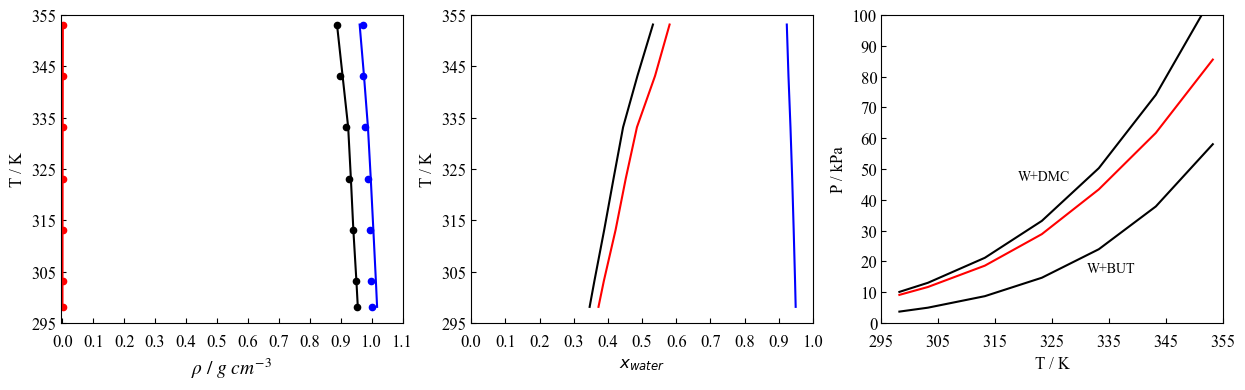

In [4]:
# Here we plot VLLE data
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams["font.family"] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Plot the 1x3 multiplot 
f, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(15, 4)) 

ax1.plot(rhAexp/1000, Texp, 'bo', markersize = 4.5)
ax1.plot(rhOexp/1000, Texp, 'ko', markersize = 4.5)
ax1.plot(rhVexp/1000, Texp, 'ro', markersize = 4.5)
ax1.plot(rhamin/1000, T, 'b-')
ax1.plot(rhomin/1000, T, 'k-')
ax1.plot(rhvmin/1000, T, 'r-')
ax1.set_ylabel('T / K')
ax1.set_xlabel(r'$\rho\ /\ g\ cm^{-3}$', math_fontfamily='stix', fontsize=14)
ax1.set_xlim([-0.005,1.1])
ax1.set_ylim([295,355])
ax1.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1])
ax1.set_yticks([295, 305, 315, 325, 335, 345, 355 ])
ax1.tick_params(axis="x", direction="in", pad=8)
ax1.tick_params(axis="y", direction="in", pad=3)

ax2.plot(xmin[:,0], T, 'b-' )
ax2.plot(wmin[:,0], T, 'r-' )
ax2.plot(ymin[:,0], T, 'k-' )
ax2.set_ylabel('T / K')
ax2.set_xlabel('$x_{water}$')
ax2.set_xlim([0,1])
ax2.set_ylim([295,355])
ax2.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax2.set_yticks([295, 305, 315, 325, 335, 345, 355 ])
ax2.tick_params(axis="x", direction="in", pad=8)
ax2.tick_params(axis="y", direction="in", pad=3)

ax3.plot(T,P12/1000, 'k-')
ax3.plot(T,P13/1000, 'k-')
ax3.plot(T,Pmin/1000, 'r-')
ax3.set_ylabel('P / kPa')
ax3.set_xlabel('T / K')
ax3.text(0.4, 0.5, 'W+DMC', fontsize=10, transform=ax3.transAxes, va='top')
ax3.text(0.6, 0.2, 'W+BUT', fontsize=10, transform=ax3.transAxes, va='top')    
ax3.set_xlim([295,355])
ax3.set_ylim([0,100])
ax3.set_xticks([295, 305, 315, 325, 335, 345, 355 ])
ax3.set_yticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100 ])
ax3.tick_params(axis="x", direction="in", pad=8)
ax3.tick_params(axis="y", direction="in", pad=3)

plt.show()

# Plot the density figure for the manuscript and save it into an external file
f, (ax1) = plt.subplots(1, 1, figsize=(4, 4)) 

ax1.plot(rhAexp/1000, Texp, 'bo', markersize = 4.5)
ax1.plot(rhOexp/1000, Texp, 'ko', markersize = 4.5)
ax1.plot(rhVexp/1000, Texp, 'ro', markersize = 4.5)
ax1.plot(rhamin/1000, T, 'b-')
ax1.plot(rhomin/1000, T, 'k-')
ax1.plot(rhvmin/1000, T, 'r-')
ax1.set_ylabel('T / K')
ax1.set_xlabel(r'$\rho\ /\ g\ cm^{-3}$', math_fontfamily='stix', fontsize=14)
ax1.set_xlim([-0.005,1.1])
ax1.set_ylim([295,355])
ax1.set_xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1])
ax1.set_yticks([295, 305, 315, 325, 335, 345, 355 ])
ax1.tick_params(axis="x", direction="in", pad=8)
ax1.tick_params(axis="y", direction="in", pad=3)

plt.savefig('Figure 3.pdf', format='pdf', bbox_inches='tight')
plt.close(f)

# Interfacial Tension Calculation

In this block we use the equilibrium ternary-triphasic points calculated previously to obtain the aqueous-vapor, organic-vapor and aqueous-organic IFT and density profiles using SGT. To that end, we loop over each temperature and first calculate a reasonably good initial guess for each profile with $\beta_{ij} = 0$ using the *sgt_mix_beta0* function. Those converge rapidly and are re-optimized with non-zero $\beta_{ij}$ values using the *msgt_mix* function.
 
#### Caution: The following cell runs in about 20 min

In [9]:
Sao,  Sav,  Sov  = np.zeros_like(T), np.zeros_like(T), np.zeros_like(T)
Rzao, Rzav, Rzov = [], [], []
zao,  zav,  zov  = [], [], []

for i in range(len(T)):
    print ("Starting 3-phase SGT for Temp = ", T[i], "K")
    ra = rhamin[i]*1000/np.sum(xmin[i]*np.array([c1.Mw, c2.Mw, c3.Mw]))*xmin[i]
    ro = rhomin[i]*1000/np.sum(wmin[i]*np.array([c1.Mw, c2.Mw, c3.Mw]))*wmin[i]
    rv = rhvmin[i]*1000/np.sum(ymin[i]*np.array([c1.Mw, c2.Mw, c3.Mw]))*ymin[i]

    solov = sgt_mix(ro, rv, T[i], Pmin[i], eos, rho0='hyperbolic', z0=50., n = 50,  dz=0.5, full_output=True)
    solav = sgt_mix(ra, rv, T[i], Pmin[i], eos, rho0='hyperbolic', z0=50., n = 50,  dz=0.5, full_output=True)
    solao = sgt_mix(ra, ro, T[i], Pmin[i], eos, rho0='hyperbolic', z0=75., n = 75,  dz=0.5, full_output=True)
    
    solov = msgt_mix(ro, rv, T[i], Pmin[i], eos, rho0=solov, z=50., n = 100,  ds=25, full_output=True)
    solav = msgt_mix(ra, rv, T[i], Pmin[i], eos, rho0=solav, z=50., n = 100,  ds=25, full_output=True)
    solao = msgt_mix(ra, ro, T[i], Pmin[i], eos, rho0=solao, z=75., n = 75,  ds=25, full_output=True)

    Sov[i],  Sav[i],  Sao[i]   = solov.tension, solav.tension, solao.tension
    zov.append(solov.z)
    zav.append(solav.z)
    zao.append(solao.z)
    Rzov.append(solov.rho)
    Rzav.append(solav.rho)
    Rzao.append(solao.rho)
zov = np.array(zov)
zav = np.array(zav)
zao = np.array(zao)
Rzov = np.array(Rzov)
Rzav = np.array(Rzav)
Rzao = np.array(Rzao)

Starting 3-phase SGT for Temp =  298.15 K
Starting 3-phase SGT for Temp =  303.15 K
Starting 3-phase SGT for Temp =  313.15 K
Starting 3-phase SGT for Temp =  323.15 K
Starting 3-phase SGT for Temp =  333.15 K
Starting 3-phase SGT for Temp =  343.15 K
Starting 3-phase SGT for Temp =  353.15 K


## IFT and Profile plotting

Once the IFTs are calculated, we plot de non-isobaric triphasic IFTs compared with experimental data. Notice that ternary-triphasic phase equilibria is obtained predictively based on binary-biphasic fitted cross-interaction parameters.

**IFTs** Experimental data points are shown in dots and *SGT* modeling is shown in lines. Blue, red and black colors correspond to the aqueous-vapor, organic-vapor and aqueous-organic phases, respectively. The dotted black line show the $\gamma^{OV}+\gamma^{WO}$ sum overlapped with the $\gamma^{WV}$ line, denoting complete wetting.

**Selected density profiles** a 3 x 1 array containing the Organic-Vapor / Aqueous-Vapor / Aqueous-Organic interfacial density profiles for the 3 components at two different temperatures ($T = 298.15 K$ and $T = 353.15 K$) are shown. Low temperature profiles are shown in solid lines, whereas high temperature profiles are shown in dashed lines. In each plot, water is represented in blue, butanol in black and DMC in red.

**All Density profiles** a 3 x 6 array containing the Organic-Vapor / Aqueous-Vapor / Aqueous-Organic interfacial density profiles at the 6 calculated temperatures are displayed. In each plot, water is represented in blue, butanol in black and DMC in red.

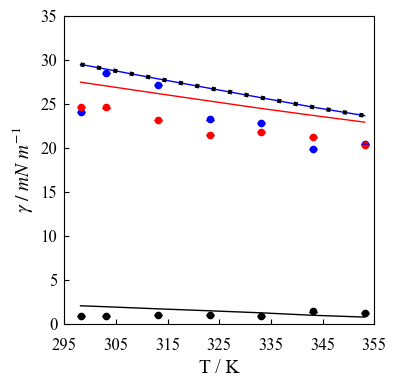

In [27]:
f, ax1 = plt.subplots(1, 1, figsize=(4, 4)) 

ax1.plot(Texp, Saoexp, 'ko', markersize=4.5)
ax1.plot(Texp, Savexp, 'bo', markersize=4.5)
ax1.plot(Texp, Sovexp, 'ro', markersize=4.5)
ax1.plot(T, Sao, 'k-', linewidth=1.0)
ax1.plot(T, Sav, 'b-', linewidth=1.0)
ax1.plot(T, Sov, 'r-', linewidth=1.0)
ax1.plot(T, Sov+Sao, 'k', linestyle=(0, (1, 3)), linewidth=3)
ax1.set_xlabel('T / K', fontsize=14)
ax1.set_ylabel(r'$\gamma\ /\ mN\ m^{-1}$', math_fontfamily='stix', fontsize=14)

ax1.set_xlim([295,355])
ax1.set_ylim([0, 35])
ax1.set_xticks([295, 305, 315, 325, 335, 345, 355])
ax1.set_yticks([0, 5, 10, 15, 20, 25, 30, 35 ])
ax1.tick_params(axis="x", direction="in", pad=10)
ax1.tick_params(axis="y", direction="in", pad=5)

plt.savefig('Figure 4.pdf', format='pdf', bbox_inches='tight')
plt.show()

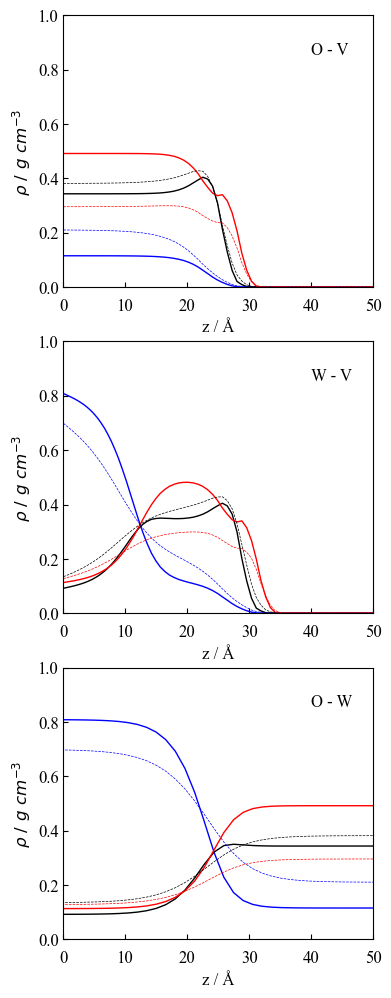

In [216]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 12)) 

ax1.plot(zov[1], Rzov[1,0]/1e6*c1.Mw,'b-', linewidth=1.)
ax1.plot(zov[1], Rzov[1,1]/1e6*c2.Mw,'k-', linewidth=1.)
ax1.plot(zov[1], Rzov[1,2]/1e6*c3.Mw,'r-', linewidth=1.)
ax1.plot(zov[6], Rzov[6,0]/1e6*c1.Mw,'b--', linewidth=0.5)
ax1.plot(zov[6], Rzov[6,1]/1e6*c2.Mw,'k--', linewidth=0.5)
ax1.plot(zov[6], Rzov[6,2]/1e6*c3.Mw,'r--', linewidth=0.5)
ax1.set_xlabel('z / Å')
ax1.set_ylabel(r'$\rho\ /\ g\ cm^{-3}$')
ax1.text(0.8, 0.9, 'O - V', fontsize=12, transform=ax1.transAxes, va='top')
ax1.set_xlim([0.,50])
ax1.set_ylim([0,1.0])
ax1.set_xticks([0, 10, 20, 30, 40, 50])
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1 ])
ax1.tick_params(axis="x", direction="in", pad=8)
ax1.tick_params(axis="y", direction="in", pad=3)



ax2.plot(zav[1], Rzav[1,0]/1e6*c1.Mw,'b-', linewidth=1.)
ax2.plot(zav[1], Rzav[1,1]/1e6*c2.Mw,'k-', linewidth=1.)
ax2.plot(zav[1], Rzav[1,2]/1e6*c3.Mw,'r-', linewidth=1.)
ax2.plot(zav[6], Rzav[6,0]/1e6*c1.Mw,'b--', linewidth=0.5)
ax2.plot(zav[6], Rzav[6,1]/1e6*c2.Mw,'k--', linewidth=0.5)
ax2.plot(zav[6], Rzav[6,2]/1e6*c3.Mw,'r--', linewidth=0.5)
ax2.set_xlabel('z / Å')
ax2.set_ylabel(r'$\rho\ /\ g\ cm^{-3}$')
ax2.text(0.8, 0.9, 'W - V', fontsize=12, transform=ax2.transAxes, va='top')
ax2.set_xlim([0.,50])
ax2.set_ylim([0,1.0])
ax2.set_xticks([0, 10, 20, 30, 40, 50])
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1 ])
ax2.tick_params(axis="x", direction="in", pad=8)
ax2.tick_params(axis="y", direction="in", pad=3)

ax3.plot(zao[1]-15, Rzao[1,0]/1e6*c1.Mw,'b-', linewidth=1.)
ax3.plot(zao[1]-15, Rzao[1,1]/1e6*c2.Mw,'k-', linewidth=1.)
ax3.plot(zao[1]-15, Rzao[1,2]/1e6*c3.Mw,'r-', linewidth=1.)
ax3.plot(zao[6]-15, Rzao[6,0]/1e6*c1.Mw,'b--', linewidth=0.5)
ax3.plot(zao[6]-15, Rzao[6,1]/1e6*c2.Mw,'k--', linewidth=0.5)
ax3.plot(zao[6]-15, Rzao[6,2]/1e6*c3.Mw,'r--', linewidth=0.5)
ax3.set_xlabel('z / Å')
ax3.set_ylabel(r'$\rho\ /\ g\ cm^{-3}$')
ax3.set_xlim(0,50)
ax3.text(0.8, 0.9, 'O - W', fontsize=12, transform=ax3.transAxes, va='top')
ax3.set_xlim([0.,50])
ax3.set_ylim([0,1.0])
ax3.set_xticks([0, 10, 20, 30, 40, 50])
ax3.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1 ])
ax3.tick_params(axis="x", direction="in", pad=8)
ax3.tick_params(axis="y", direction="in", pad=3)

plt.savefig('Figure 5.pdf', format='pdf', bbox_inches='tight')
plt.show()

## All density profiles

A 3 x 6 array containing the Organic-Vapor / Aqueous-Vapor / Aqueous-Organic interfacial density profiles at the 6 calculated temperatures are displayed. In each plot, water is represented in blue, butanol in black and DMC in red.

**Note: The plots shown in the following block are given for completeness and are not shown in the original manuscript**

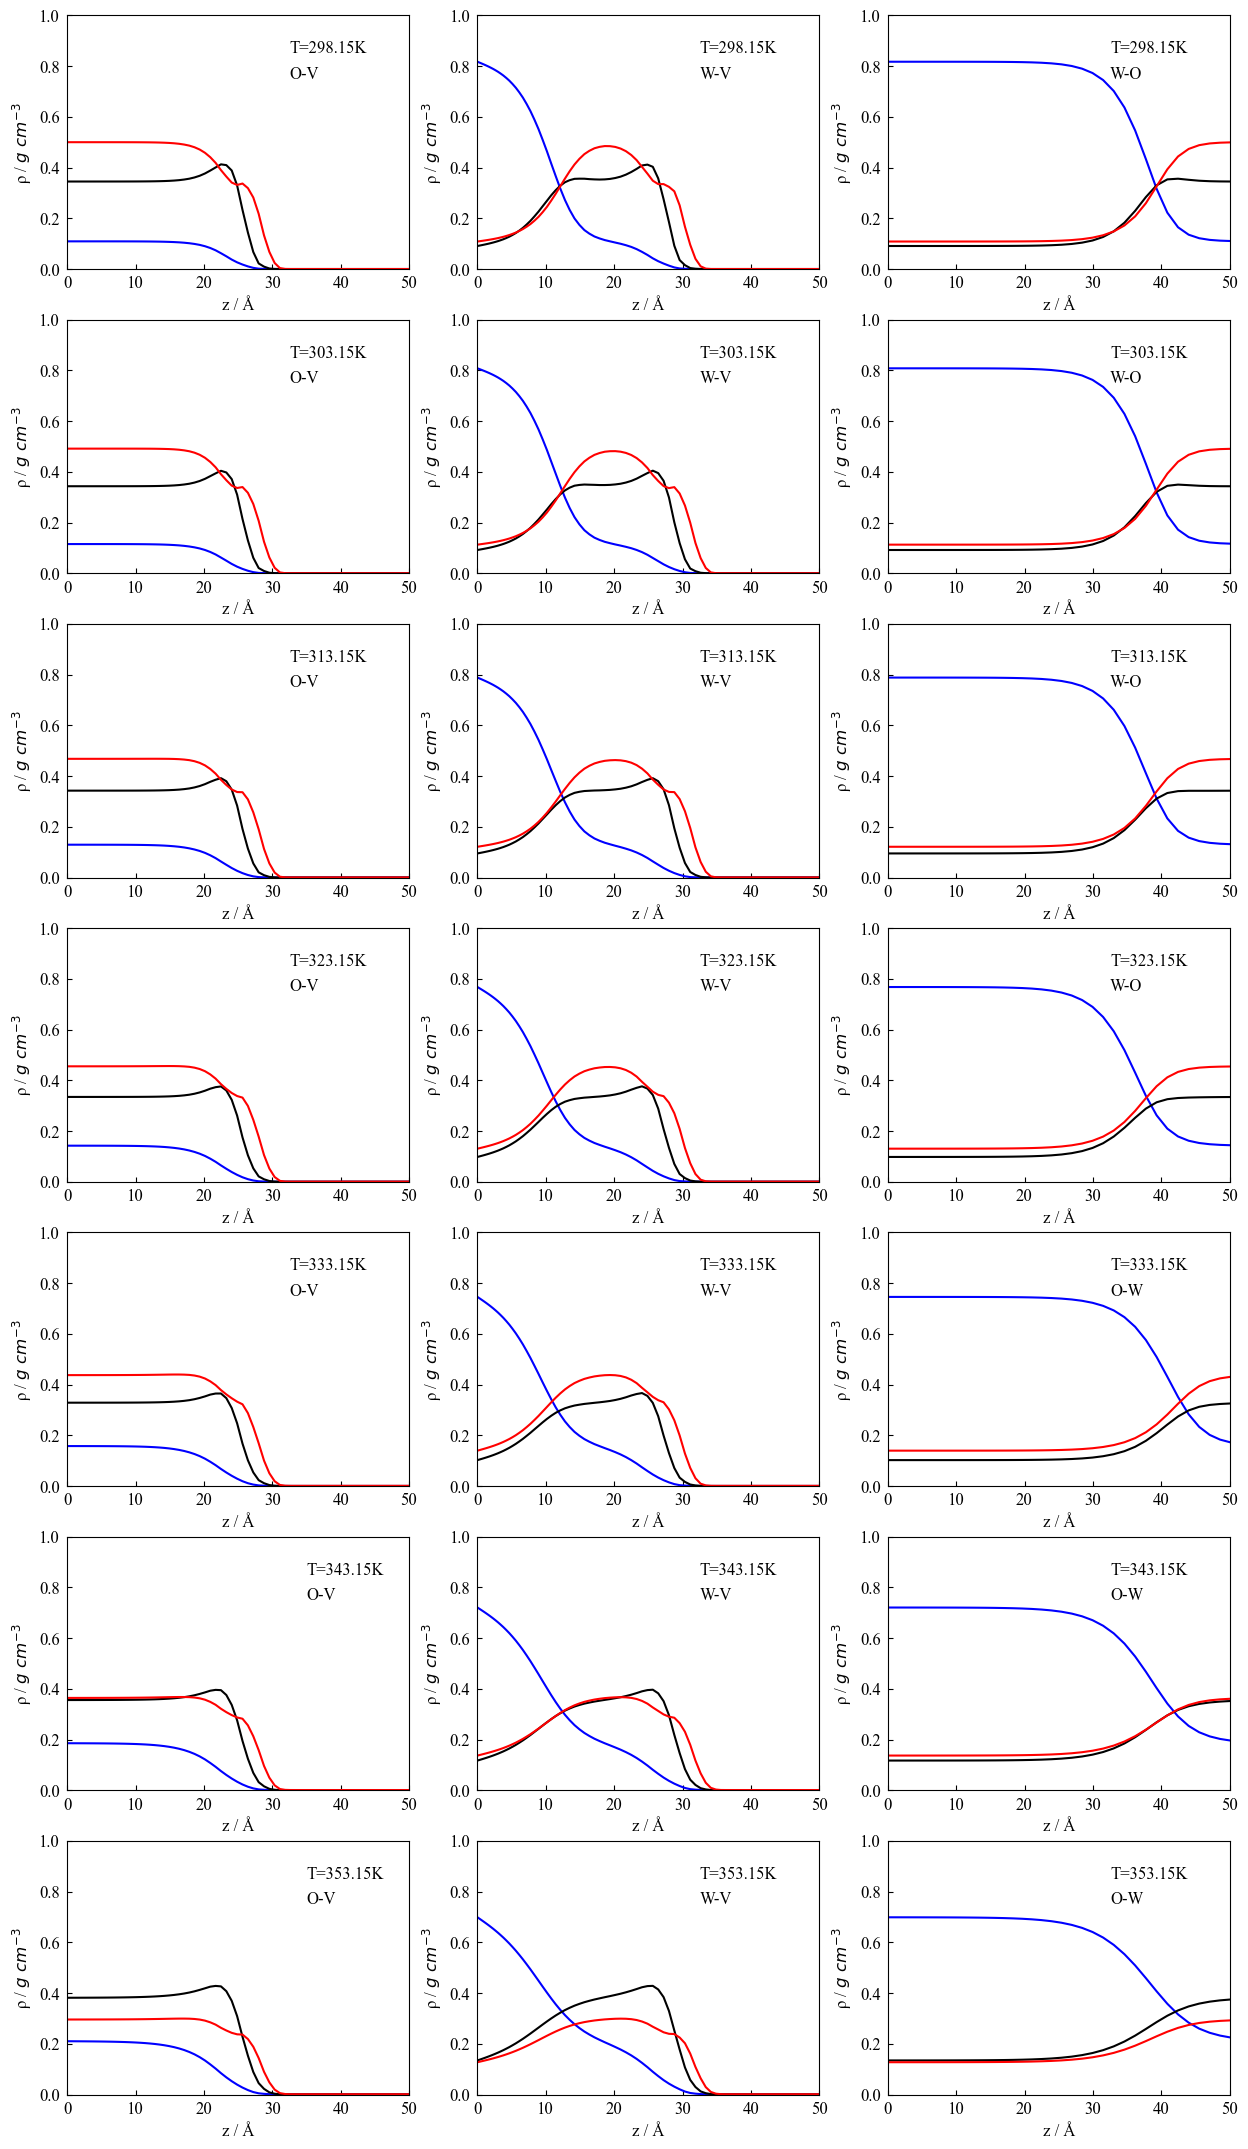

In [201]:
f, ((ax1, ax2, ax3),(ax4, ax5, ax6),(ax7, ax8, ax9),(ax10, ax11, ax12),(ax13, ax14, ax15),(ax16, ax17, ax18),(ax19, ax20, ax21)) = plt.subplots(7, 3, figsize=(15, 27)) 

ax1.set_xlim([0.,50])
ax2.set_xlim([0.,50])
ax3.set_xlim([0.,50])
ax4.set_xlim([0.,50])
ax5.set_xlim([0.,50])
ax6.set_xlim([0.,50])
ax7.set_xlim([0.,50])
ax8.set_xlim([0.,50])
ax9.set_xlim([0.,50])
ax10.set_xlim([0.,50])
ax11.set_xlim([0.,50])
ax12.set_xlim([0.,50])
ax13.set_xlim([0.,50])
ax14.set_xlim([0.,50])
ax15.set_xlim([0.,50])
ax16.set_xlim([0.,50])
ax17.set_xlim([0.,50])
ax18.set_xlim([0.,50])
ax19.set_xlim([0.,50])
ax20.set_xlim([0.,50])
ax21.set_xlim([0.,50])

ax1.set_ylim([0,1.0])
ax2.set_ylim([0,1.0])
ax3.set_ylim([0,1.0])
ax4.set_ylim([0,1.0])
ax5.set_ylim([0,1.0])
ax6.set_ylim([0,1.0])
ax7.set_ylim([0,1.0])
ax8.set_ylim([0,1.0])
ax9.set_ylim([0,1.0])
ax10.set_ylim([0,1.0])
ax11.set_ylim([0,1.0])
ax12.set_ylim([0,1.0])
ax13.set_ylim([0,1.0])
ax14.set_ylim([0,1.0])
ax15.set_ylim([0,1.0])
ax16.set_ylim([0,1.0])
ax17.set_ylim([0,1.0])
ax18.set_ylim([0,1.0])
ax19.set_ylim([0,1.0])
ax20.set_ylim([0,1.0])
ax21.set_ylim([0,1.0])

ax1.tick_params(axis="both", direction="in", pad=5)
ax2.tick_params(axis="both", direction="in", pad=5)
ax3.tick_params(axis="both", direction="in", pad=5)
ax4.tick_params(axis="both", direction="in", pad=5)
ax5.tick_params(axis="both", direction="in", pad=5)
ax6.tick_params(axis="both", direction="in", pad=5)
ax7.tick_params(axis="both", direction="in", pad=5)
ax8.tick_params(axis="both", direction="in", pad=5)
ax9.tick_params(axis="both", direction="in", pad=5)
ax10.tick_params(axis="both", direction="in", pad=5)
ax11.tick_params(axis="both", direction="in", pad=5)
ax12.tick_params(axis="both", direction="in", pad=5)
ax13.tick_params(axis="both", direction="in", pad=5)
ax14.tick_params(axis="both", direction="in", pad=5)
ax15.tick_params(axis="both", direction="in", pad=5)
ax16.tick_params(axis="both", direction="in", pad=5)
ax17.tick_params(axis="both", direction="in", pad=5)
ax18.tick_params(axis="both", direction="in", pad=5)
ax19.tick_params(axis="both", direction="in", pad=5)
ax20.tick_params(axis="both", direction="in", pad=5)
ax21.tick_params(axis="both", direction="in", pad=5)




ax1.plot(zov[0], Rzov[0,0]/1e6*c1.Mw,'b-')
ax1.plot(zov[0], Rzov[0,1]/1e6*c2.Mw,'k-')
ax1.plot(zov[0], Rzov[0,2]/1e6*c3.Mw,'r-')
ax1.set_xlabel('z / Å')
ax1.set_ylabel('ρ / $g\ cm^{-3}$')
ax1.text(0.65, 0.9, 'T='+str(T[0])+"K", fontsize=12, transform=ax1.transAxes, va='top')
ax1.text(0.65, 0.8, 'O-V', fontsize=12, transform=ax1.transAxes, va='top')
ax2.plot(zav[0], Rzav[0,0]/1e6*c1.Mw,'b-')
ax2.plot(zav[0], Rzav[0,1]/1e6*c2.Mw,'k-')
ax2.plot(zav[0], Rzav[0,2]/1e6*c3.Mw,'r-')
ax2.set_xlabel('z / Å')
ax2.set_ylabel('ρ / $g\ cm^{-3}$')
ax2.text(0.65, 0.9, 'T='+str(T[0])+"K", fontsize=12, transform=ax2.transAxes, va='top')
ax2.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax2.transAxes, va='top')
ax3.plot(zao[0], Rzao[0,0]/1e6*c1.Mw,'b-')
ax3.plot(zao[0], Rzao[0,1]/1e6*c2.Mw,'k-')
ax3.plot(zao[0], Rzao[0,2]/1e6*c3.Mw,'r-')
ax3.set_xlabel('z / Å')
ax3.set_ylabel('ρ / $g\ cm^{-3}$')
ax3.text(0.65, 0.9, 'T='+str(T[0])+"K", fontsize=12, transform=ax3.transAxes, va='top')
ax3.text(0.65, 0.8, 'W-O', fontsize=12, transform=ax3.transAxes, va='top')

ax4.plot(zov[1], Rzov[1,0]/1e6*c1.Mw,'b-')
ax4.plot(zov[1], Rzov[1,1]/1e6*c2.Mw,'k-')
ax4.plot(zov[1], Rzov[1,2]/1e6*c3.Mw,'r-')
ax4.set_xlabel('z / Å')
ax4.set_ylabel('ρ / $g\ cm^{-3}$')
ax4.text(0.65, 0.9, 'T='+str(T[1])+"K", fontsize=12, transform=ax4.transAxes, va='top')
ax4.text(0.65, 0.8, 'O-V', fontsize=12, transform=ax4.transAxes, va='top')
ax5.plot(zav[1], Rzav[1,0]/1e6*c1.Mw,'b-')
ax5.plot(zav[1], Rzav[1,1]/1e6*c2.Mw,'k-')
ax5.plot(zav[1], Rzav[1,2]/1e6*c3.Mw,'r-')
ax5.set_xlabel('z / Å')
ax5.set_ylabel('ρ / $g\ cm^{-3}$')
ax5.text(0.65, 0.9, 'T='+str(T[1])+"K", fontsize=12, transform=ax5.transAxes, va='top')
ax5.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax5.transAxes, va='top')
ax6.plot(zao[1], Rzao[1,0]/1e6*c1.Mw,'b-')
ax6.plot(zao[1], Rzao[1,1]/1e6*c2.Mw,'k-')
ax6.plot(zao[1], Rzao[1,2]/1e6*c3.Mw,'r-')
ax6.set_xlabel('z / Å')
ax6.set_ylabel('ρ / $g\ cm^{-3}$')
ax6.text(0.65, 0.9, 'T='+str(T[1])+"K", fontsize=12, transform=ax6.transAxes, va='top')
ax6.text(0.65, 0.8, 'W-O', fontsize=12, transform=ax6.transAxes, va='top')

ax7.plot(zov[2], Rzov[2,0]/1e6*c1.Mw,'b-')
ax7.plot(zov[2], Rzov[2,1]/1e6*c2.Mw,'k-')
ax7.plot(zov[2], Rzov[2,2]/1e6*c3.Mw,'r-')
ax7.set_xlabel('z / Å')
ax7.set_ylabel('ρ / $g\ cm^{-3}$')
ax7.text(0.65, 0.9, 'T='+str(T[2])+"K", fontsize=12, transform=ax7.transAxes, va='top')
ax7.text(0.65, 0.8, 'O-V', fontsize=12, transform=ax7.transAxes, va='top')
ax8.plot(zav[2], Rzav[2,0]/1e6*c1.Mw,'b-')
ax8.plot(zav[2], Rzav[2,1]/1e6*c2.Mw,'k-')
ax8.plot(zav[2], Rzav[2,2]/1e6*c3.Mw,'r-')
ax8.set_xlabel('z / Å')
ax8.set_ylabel('ρ / $g\ cm^{-3}$')
ax8.text(0.65, 0.9, 'T='+str(T[2])+"K", fontsize=12, transform=ax8.transAxes, va='top')
ax8.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax8.transAxes, va='top')
ax9.plot(zao[2], Rzao[2,0]/1e6*c1.Mw,'b-')
ax9.plot(zao[2], Rzao[2,1]/1e6*c2.Mw,'k-')
ax9.plot(zao[2], Rzao[2,2]/1e6*c3.Mw,'r-')
ax9.set_xlabel('z / Å')
ax9.set_ylabel('ρ / $g\ cm^{-3}$')
ax9.text(0.65, 0.9, 'T='+str(T[2])+"K", fontsize=12, transform=ax9.transAxes, va='top')
ax9.text(0.65, 0.8, 'W-O', fontsize=12, transform=ax9.transAxes, va='top')

ax10.plot(zov[3], Rzov[3,0]/1e6*c1.Mw,'b-')
ax10.plot(zov[3], Rzov[3,1]/1e6*c2.Mw,'k-')
ax10.plot(zov[3], Rzov[3,2]/1e6*c3.Mw,'r-')
ax10.set_xlabel('z / Å')
ax10.set_ylabel('ρ / $g\ cm^{-3}$')
ax10.text(0.65, 0.9, 'T='+str(T[3])+"K", fontsize=12, transform=ax10.transAxes, va='top')
ax10.text(0.65, 0.8, 'O-V', fontsize=12, transform=ax10.transAxes, va='top')
ax11.plot(zav[3], Rzav[3,0]/1e6*c1.Mw,'b-')
ax11.plot(zav[3], Rzav[3,1]/1e6*c2.Mw,'k-')
ax11.plot(zav[3], Rzav[3,2]/1e6*c3.Mw,'r-')
ax11.set_xlabel('z / Å')
ax11.set_ylabel('ρ / $g\ cm^{-3}$')
ax11.text(0.65, 0.9, 'T='+str(T[3])+"K", fontsize=12, transform=ax11.transAxes, va='top')
ax11.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax11.transAxes, va='top')
ax12.plot(zao[3], Rzao[3,0]/1e6*c1.Mw,'b-')
ax12.plot(zao[3], Rzao[3,1]/1e6*c2.Mw,'k-')
ax12.plot(zao[3], Rzao[3,2]/1e6*c3.Mw,'r-')
ax12.set_xlabel('z / Å')
ax12.set_ylabel('ρ / $g\ cm^{-3}$')
ax12.text(0.65, 0.9, 'T='+str(T[3])+"K", fontsize=12, transform=ax12.transAxes, va='top')
ax12.text(0.65, 0.8, 'W-O', fontsize=12, transform=ax12.transAxes, va='top')

ax13.plot(zov[4], Rzov[4,0]/1e6*c1.Mw,'b-')
ax13.plot(zov[4], Rzov[4,1]/1e6*c2.Mw,'k-')
ax13.plot(zov[4], Rzov[4,2]/1e6*c3.Mw,'r-')
ax13.set_xlabel('z / Å')
ax13.set_ylabel('ρ / $g\ cm^{-3}$')
ax13.text(0.65, 0.8, 'O-V', fontsize=12, transform=ax13.transAxes, va='top')
ax13.text(0.65, 0.9, 'T='+str(T[4])+"K", fontsize=12, transform=ax13.transAxes, va='top')
ax14.plot(zav[4], Rzav[4,0]/1e6*c1.Mw,'b-')
ax14.plot(zav[4], Rzav[4,1]/1e6*c2.Mw,'k-')
ax14.plot(zav[4], Rzav[4,2]/1e6*c3.Mw,'r-')
ax14.set_xlabel('z / Å')
ax14.set_ylabel('ρ / $g\ cm^{-3}$')
ax14.text(0.65, 0.9, 'T='+str(T[4])+"K", fontsize=12, transform=ax14.transAxes, va='top')
ax14.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax14.transAxes, va='top')
ax15.plot(zao[4], Rzao[4,0]/1e6*c1.Mw,'b-')
ax15.plot(zao[4], Rzao[4,1]/1e6*c2.Mw,'k-')
ax15.plot(zao[4], Rzao[4,2]/1e6*c3.Mw,'r-')
ax15.set_xlabel('z / Å')
ax15.set_ylabel('ρ / $g\ cm^{-3}$')
ax15.text(0.65, 0.9, 'T='+str(T[4])+"K", fontsize=12, transform=ax15.transAxes, va='top')
ax15.text(0.65, 0.8, 'O-W', fontsize=12, transform=ax15.transAxes, va='top')

ax16.plot(zov[5], Rzov[5,0]/1e6*c1.Mw,'b-')
ax16.plot(zov[5], Rzov[5,1]/1e6*c2.Mw,'k-')
ax16.plot(zov[5], Rzov[5,2]/1e6*c3.Mw,'r-')
ax16.set_xlabel('z / Å')
ax16.set_ylabel('ρ / $g\ cm^{-3}$')
ax16.text(0.7, 0.8, 'O-V', fontsize=12, transform=ax16.transAxes, va='top')
ax16.text(0.7, 0.9, 'T='+str(T[5])+"K", fontsize=12, transform=ax16.transAxes, va='top')
ax17.plot(zav[5], Rzav[5,0]/1e6*c1.Mw,'b-')
ax17.plot(zav[5], Rzav[5,1]/1e6*c2.Mw,'k-')
ax17.plot(zav[5], Rzav[5,2]/1e6*c3.Mw,'r-')
ax17.set_xlabel('z / Å')
ax17.set_ylabel('ρ / $g\ cm^{-3}$')
ax17.text(0.65, 0.9, 'T='+str(T[5])+"K", fontsize=12, transform=ax17.transAxes, va='top')
ax17.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax17.transAxes, va='top')
ax18.plot(zao[5], Rzao[5,0]/1e6*c1.Mw,'b-')
ax18.plot(zao[5], Rzao[5,1]/1e6*c2.Mw,'k-')
ax18.plot(zao[5], Rzao[5,2]/1e6*c3.Mw,'r-')
ax18.set_xlabel('z / Å')
ax18.set_ylabel('ρ / $g\ cm^{-3}$')
ax18.text(0.65, 0.9, 'T='+str(T[5])+"K", fontsize=12, transform=ax18.transAxes, va='top')
ax18.text(0.65, 0.8, 'O-W', fontsize=12, transform=ax18.transAxes, va='top')

ax19.plot(zov[6], Rzov[6,0]/1e6*c1.Mw,'b-')
ax19.plot(zov[6], Rzov[6,1]/1e6*c2.Mw,'k-')
ax19.plot(zov[6], Rzov[6,2]/1e6*c3.Mw,'r-')
ax19.set_xlabel('z / Å')
ax19.set_ylabel('ρ / $g\ cm^{-3}$')
ax19.text(0.7, 0.9, 'T='+str(T[6])+"K", fontsize=12, transform=ax19.transAxes, va='top')
ax19.text(0.7, 0.8, 'O-V', fontsize=12, transform=ax19.transAxes, va='top')
ax20.plot(zav[6], Rzav[6,0]/1e6*c1.Mw,'b-')
ax20.plot(zav[6], Rzav[6,1]/1e6*c2.Mw,'k-')
ax20.plot(zav[6], Rzav[6,2]/1e6*c3.Mw,'r-')
ax20.set_xlabel('z / Å')
ax20.set_ylabel('ρ / $g\ cm^{-3}$')
ax20.text(0.65, 0.9, 'T='+str(T[6])+"K", fontsize=12, transform=ax20.transAxes, va='top')
ax20.text(0.65, 0.8, 'W-V', fontsize=12, transform=ax20.transAxes, va='top')
ax21.plot(zao[6], Rzao[6,0]/1e6*c1.Mw,'b-')
ax21.plot(zao[6], Rzao[6,1]/1e6*c2.Mw,'k-')
ax21.plot(zao[6], Rzao[6,2]/1e6*c3.Mw,'r-')
ax21.set_xlabel('z / Å')
ax21.set_ylabel('ρ / $g\ cm^{-3}$')
ax21.text(0.65, 0.9, 'T='+str(T[6])+"K", fontsize=12, transform=ax21.transAxes, va='top')
ax21.text(0.65, 0.8, 'O-W', fontsize=12, transform=ax21.transAxes, va='top')

plt.show()